# Step 3: Data Augmentation — Cluster Regression

流程：對 `new_features.csv` 做 log1p 轉換 → 相關係數選特徵 → Elbow Method 找最佳 k → KMeans 在 (log_p, log_q) 空間分群 → 各 cluster 內跑 LinearRegression → 對 `hist_features.csv` 推估 P/Q/constant，M 直接取 views。

In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['font.family'] = 'Arial Unicode MS'

In [224]:
PROCESSED = Path('../data/processed')
OUTPUT    = Path('../data/output')
OUTPUT.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED / 'new_features.csv')
print('new_features shape:', df.shape)

new_features shape: (224, 1084)


## 1. 資料準備

In [225]:
# log1p 轉換
df['log_p']        = np.log1p(df['p_after4d'])
df['log_q']        = np.log1p(df['q_after4d'])
df['log_constant'] = np.log1p(df['constant_after4d_time0_views'])

# LabelEncoder（加入 'unknown' 確保 hist 未見 label 不會報錯）
le = LabelEncoder()
le.fit(df['best_topic_labels'].fillna('unknown').unique().tolist() + ['unknown'])
df['best_topic_labels_enc'] = le.transform(df['best_topic_labels'].fillna('unknown'))

# AI業配判定 → 0/1
df['AI業配判定_enc'] = (
    df['AI業配判定']
    .map({True: 1, 'True': 1, False: 0, 'False': 0})
    .fillna(0).astype(int)
)

print('log_p     :', round(df['log_p'].min(), 4), '~', round(df['log_p'].max(), 4))
print('log_q     :', round(df['log_q'].min(), 4), '~', round(df['log_q'].max(), 4))
print('log_const :', round(df['log_constant'].min(), 4), '~', round(df['log_constant'].max(), 4))

log_p     : 0.0 ~ 0.4674
log_q     : 0.0 ~ 0.6855
log_const : 0.0 ~ 14.1863


/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_26361/2858229115.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['log_p']        = np.log1p(df['p_after4d'])
/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_26361/2858229115.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['log_q']        = np.log1p(df['q_after4d'])
/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_26361/2858229115.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inse

In [226]:
# 特徵選擇：計算各候選特徵與 log_p、log_q 的相關係數，取 top 5
emb_new_cols   = [c for c in df.columns if c.startswith('emb_new_')]
candidate_cols = ['duration', 'best_topic_labels_enc', 'AI業配判定_enc'] + emb_new_cols

feat_filled = df[candidate_cols].apply(lambda col: col.fillna(col.median()))
medians_sel  = feat_filled.median()

corr_p = feat_filled.corrwith(df['log_p']).abs()
corr_q = feat_filled.corrwith(df['log_q']).abs()
feat_corr = (
    pd.DataFrame({'corr_p': corr_p, 'corr_q': corr_q})
    .assign(max_corr=lambda x: x.max(axis=1))
    .sort_values('max_corr', ascending=False)
)

TOP_N             = 5
selected_features = feat_corr.head(TOP_N).index.tolist()
print(f'Top {TOP_N} 特徵（依與 log_p/log_q 的最大相關係數）：')
print(feat_corr.head(10).to_string())

Top 5 特徵（依與 log_p/log_q 的最大相關係數）：
               corr_p    corr_q  max_corr
emb_new_256  0.185995  0.243162  0.243162
emb_new_095  0.038649  0.237635  0.237635
duration     0.064928  0.232809  0.232809
emb_new_067  0.078668  0.223105  0.223105
emb_new_409  0.051357  0.211776  0.211776
emb_new_133  0.085619  0.209946  0.209946
emb_new_326  0.118834  0.209200  0.209200
emb_new_817  0.077802  0.206588  0.206588
emb_new_524  0.163633  0.204414  0.204414
emb_new_750  0.195291  0.063286  0.195291


In [227]:
# 特徵矩陣：StandardScaler fit 在全部 223 筆
scaler = StandardScaler()
X_all  = scaler.fit_transform(feat_filled[selected_features].values)
print('X_all shape:', X_all.shape)

X_all shape: (224, 5)


## 2. Elbow Method（基於 log_p, log_q 空間）

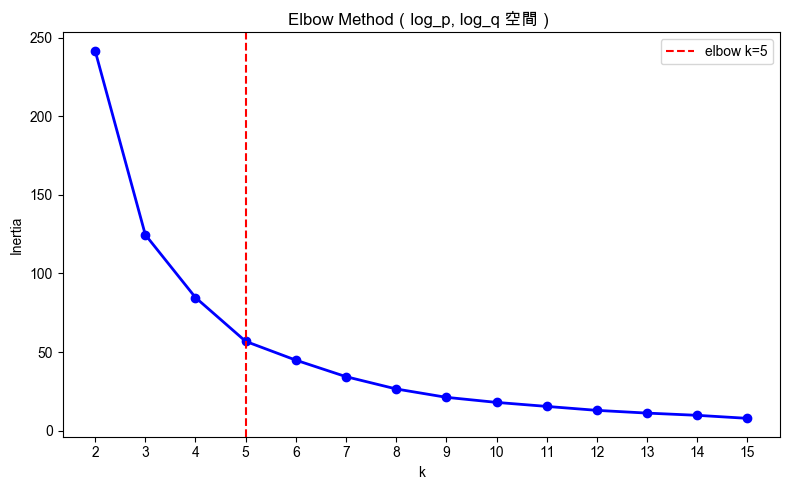

自動偵測 best_k = 5


In [228]:
scaler_cluster = StandardScaler()
X_cluster      = scaler_cluster.fit_transform(df[['log_p', 'log_q']].values)

inertias = []
K_range  = range(2, 16)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

# Kneedle 法自動偵測 elbow
k_arr   = np.array(list(K_range), dtype=float)
ine_arr = np.array(inertias)
k_n     = (k_arr - k_arr[0]) / (k_arr[-1] - k_arr[0])
i_n     = (ine_arr - ine_arr[-1]) / (ine_arr[0] - ine_arr[-1])
best_k  = int(k_arr[np.argmax(np.abs(k_n + i_n - 1) / np.sqrt(2))])
best_k  = max(3, best_k)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_range), inertias, 'bo-', linewidth=2)
ax.axvline(x=best_k, color='red', linestyle='--', label=f'elbow k={best_k}')
ax.set_xlabel('k')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method（log_p, log_q 空間）')
ax.set_xticks(list(K_range))
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT / 'elbow.png', dpi=150)
plt.show()
print(f'自動偵測 best_k = {best_k}')

## 3. KMeans 分群

In [229]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster)

print('各 Cluster 大小：')
print(df['cluster'].value_counts().sort_index().to_string())

各 Cluster 大小：
cluster
0    69
1    46
2    59
3    12
4    38


/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_26361/939471405.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster'] = kmeans.fit_predict(X_cluster)


## 4. Train/Test Split（80/20，stratified by cluster）

In [230]:
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42,
    stratify=df['cluster'].values
)

print(f'train: {len(train_idx)} 筆, test: {len(test_idx)} 筆')
print('train cluster 分布：')
print(pd.Series(df['cluster'].values[train_idx]).value_counts().sort_index().to_string())

train: 179 筆, test: 45 筆
train cluster 分布：
0    55
1    37
2    47
3    10
4    30


## 5. Per-Cluster LinearRegression + 評估

In [231]:
targets         = ['log_p', 'log_q', 'log_constant']
global_fallback = {t: df[t].median() for t in targets}

cluster_models = {}
for c in range(best_k):
    mask_c = df['cluster'].values[train_idx] == c
    n_c    = mask_c.sum()
    if n_c < 2:
        print(f'Cluster {c}: 只有 {n_c} 筆 train，使用全體中位數 fallback')
        cluster_models[c] = None
        continue
    X_c = X_all[train_idx][mask_c]
    cluster_models[c] = {
        t: LinearRegression().fit(X_c, df[t].values[train_idx][mask_c])
        for t in targets
    }
    print(f'Cluster {c}: {n_c} 筆 train → 迴歸完成')

Cluster 0: 55 筆 train → 迴歸完成
Cluster 1: 37 筆 train → 迴歸完成
Cluster 2: 47 筆 train → 迴歸完成
Cluster 3: 10 筆 train → 迴歸完成
Cluster 4: 30 筆 train → 迴歸完成


In [232]:
rows = []
for c in range(best_k):
    mask_c = df['cluster'].values[test_idx] == c
    if mask_c.sum() == 0:
        continue
    X_tc = X_all[test_idx][mask_c]
    for t in targets:
        y_true = df[t].values[test_idx][mask_c]
        y_pred = (
            cluster_models[c][t].predict(X_tc)
            if cluster_models[c] is not None
            else np.full(mask_c.sum(), global_fallback[t])
        )
        rows.append({
            'cluster': c,
            'target' : t,
            'n_test' : int(mask_c.sum()),
            'MAE'    : mean_absolute_error(y_true, y_pred),
            'RMSE'   : np.sqrt(mean_squared_error(y_true, y_pred)),
        })

eval_df = pd.DataFrame(rows)
print(eval_df.to_string(index=False))
print(f'\n整體 RMSE 總和：{eval_df["RMSE"].sum():.4f}')

 cluster       target  n_test      MAE     RMSE
       0        log_p      14 0.028058 0.032910
       0        log_q      14 0.011370 0.039105
       0 log_constant      14 0.902680 1.089120
       1        log_p       9 0.014980 0.031496
       1        log_q       9 0.068115 0.079482
       1 log_constant       9 1.693386 3.274311
       2        log_p      12 0.016072 0.021491
       2        log_q      12 0.023679 0.033019
       2 log_constant      12 1.261603 1.593382
       3        log_p       2 0.139460 0.161071
       3        log_q       2 0.108703 0.109461
       3 log_constant       2 2.739070 3.264966
       4        log_p       8 0.062761 0.093917
       4        log_q       8 0.013962 0.016333
       4 log_constant       8 2.340469 3.484349

整體 RMSE 總和：13.3244


In [233]:
from sklearn.metrics import r2_score

# ── 1. Per-Cluster R²（test set）──
print('=== Per-Cluster R²（test set）===')
r2_rows = []
for c in range(best_k):
    mask_c = df['cluster'].values[test_idx] == c
    if mask_c.sum() == 0:
        continue
    X_tc = X_all[test_idx][mask_c]
    for t in targets:
        y_true = df[t].values[test_idx][mask_c]
        if cluster_models[c] is not None:
            r2 = r2_score(y_true, cluster_models[c][t].predict(X_tc))
        else:
            r2 = float('nan')
        r2_rows.append({'cluster': c, 'target': t,
                        'n_test': int(mask_c.sum()), 'R²': round(r2, 4)})

print(pd.DataFrame(r2_rows).to_string(index=False))

# ── 2. Intra-Cluster Distance（KMeans 空間，log_p / log_q）──
print('\n=== Intra-Cluster Distance（平均 / 最大距離到 cluster 中心）===')
centroids = kmeans.cluster_centers_          # (best_k, 2)，已在 scaled 空間
for c in range(best_k):
    mask_c = df['cluster'].values == c
    dists  = np.linalg.norm(X_cluster[mask_c] - centroids[c], axis=1)
    print(f'Cluster {c}（{mask_c.sum():3d} 筆）：'
          f'平均距離 = {dists.mean():.4f}，最大距離 = {dists.max():.4f}')

=== Per-Cluster R²（test set）===
 cluster       target  n_test          R²
       0        log_p      14     -0.6056
       0        log_q      14     -0.0534
       0 log_constant      14      0.1344
       1        log_p       9     -0.2777
       1        log_q       9     -0.1217
       1 log_constant       9      0.0697
       2        log_p      12     -0.5158
       2        log_q      12     -0.5000
       2 log_constant      12     -0.1344
       3        log_p       2     -0.3315
       3        log_q       2    -69.6459
       3 log_constant       2     -0.2422
       4        log_p       8     -0.1722
       4        log_q       8 -61051.7235
       4 log_constant       8      0.1757

=== Intra-Cluster Distance（平均 / 最大距離到 cluster 中心）===
Cluster 0（ 69 筆）：平均距離 = 0.3021，最大距離 = 1.0343
Cluster 1（ 46 筆）：平均距離 = 0.3744，最大距離 = 1.2471
Cluster 2（ 59 筆）：平均距離 = 0.2563，最大距離 = 0.5783
Cluster 3（ 12 筆）：平均距離 = 0.9584，最大距離 = 2.7613
Cluster 4（ 38 筆）：平均距離 = 0.4739，最大距離 = 2.7190


=== 各 Cluster log_p / log_q 分布 ===

Cluster 0（69 筆）
       log_p   log_q
min   0.0633  0.0000
max   0.1708  0.1479
mean  0.1160  0.0026
std   0.0291  0.0181

Cluster 1（46 筆）
       log_p   log_q
min   0.0000  0.1167
max   0.0712  0.3658
mean  0.0030  0.1903
std   0.0138  0.0639

Cluster 2（59 筆）
       log_p   log_q
min   0.0000  0.0000
max   0.0604  0.1044
mean  0.0119  0.0256
std   0.0191  0.0291

Cluster 3（12 筆）
       log_p   log_q
min   0.0000  0.4085
max   0.2792  0.6855
mean  0.0408  0.5518
std   0.0873  0.0922

Cluster 4（38 筆）
       log_p   log_q
min   0.1757  0.0000
max   0.4674  0.2699
mean  0.2269  0.0071
std   0.0540  0.0438

=== 離群值（距 cluster 中心 > 2σ）===
Cluster 0：1 筆離群值
  DXCP-UlCQVK  log_p=0.1107  log_q=0.1479  dist=1.0343
Cluster 1：4 筆離群值
  DW87B9svm6u  log_p=0.0000  log_q=0.3658  dist=1.2471
  DXCFjQsjwGZ  log_p=0.0000  log_q=0.3351  dist=1.0291
  DXMYZvKESmT  log_p=0.0000  log_q=0.3383  dist=1.0517
  DXRXf8Bk_k3  log_p=0.0000  log_q=0.3386  dist=1.0541
Cluster 2：3 筆離群

/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_26361/3413957481.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10', best_k)


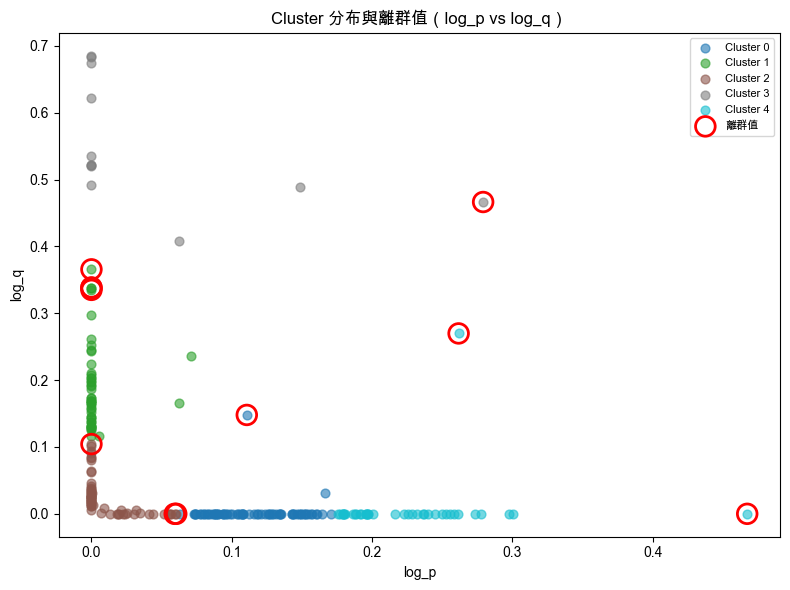

已儲存：../data/output/cluster_outliers.png


In [234]:
outlier_idx_all = []

# ── 1. 各 cluster 的 log_p / log_q 分布 ──
print('=== 各 Cluster log_p / log_q 分布 ===')
for c in range(best_k):
    mask_c = df['cluster'].values == c
    sub    = df.loc[mask_c, ['log_p', 'log_q']]
    print(f'\nCluster {c}（{mask_c.sum()} 筆）')
    print(sub.agg(['min', 'max', 'mean', 'std']).round(4).to_string())

# ── 2. 各 cluster 內距離中心 > 2σ 的離群值 ──
print('\n=== 離群值（距 cluster 中心 > 2σ）===')
for c in range(best_k):
    mask_c  = df['cluster'].values == c
    X_c     = X_cluster[mask_c]
    dists   = np.linalg.norm(X_c - kmeans.cluster_centers_[c], axis=1)
    thr     = dists.mean() + 2 * dists.std()
    is_out  = dists > thr
    out_idx = np.where(mask_c)[0][is_out]
    outlier_idx_all.extend(out_idx.tolist())
    if is_out.sum() == 0:
        print(f'Cluster {c}：無離群值')
    else:
        print(f'Cluster {c}：{is_out.sum()} 筆離群值')
        for i in out_idx:
            print(f'  {df["reels_shortcode"].iloc[i]}  '
                  f'log_p={df["log_p"].iloc[i]:.4f}  '
                  f'log_q={df["log_q"].iloc[i]:.4f}  '
                  f'dist={dists[is_out][list(out_idx).index(i)]:.4f}')

# ── 3. 散點圖 ──
cmap   = plt.cm.get_cmap('tab10', best_k)
fig, ax = plt.subplots(figsize=(8, 6))

for c in range(best_k):
    mask_c = df['cluster'].values == c
    ax.scatter(df.loc[mask_c, 'log_p'], df.loc[mask_c, 'log_q'],
               color=cmap(c), alpha=0.6, s=40, label=f'Cluster {c}')

# 離群值：紅色大圓圈
if outlier_idx_all:
    out_df_plot = df.iloc[outlier_idx_all]
    ax.scatter(out_df_plot['log_p'], out_df_plot['log_q'],
               facecolors='none', edgecolors='red', linewidths=2,
               s=200, zorder=5, label='離群值')

ax.set_xlabel('log_p')
ax.set_ylabel('log_q')
ax.set_title('Cluster 分布與離群值（log_p vs log_q）')
ax.legend(fontsize=8)
plt.tight_layout()
viz_path = OUTPUT / 'cluster_outliers.png'
plt.savefig(viz_path, dpi=150)
plt.show()
print(f'已儲存：{viz_path}')

有效樣本數：224
距離矩陣 shape：(224, 224)
非零距離  min=0.0000  max=19.8855  mean=1.7155

各 KL Cluster 大小：
kl_cluster
0    118
1     16
2     87
3      1
4      2

各 Cluster p_after4d / q_after4d mean & std：
           p_after4d          q_after4d         
                mean      std      mean      std
kl_cluster                                      
0            0.16358  0.08407   0.02269  0.10006
1            0.00000  0.00000   0.47771  0.19823
2            0.00428  0.01024   0.08596  0.07787
3            0.00000      NaN   0.98468      NaN
4            0.00000  0.00000   0.97227  0.01281


/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_26361/2078655489.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_kl = plt.cm.get_cmap('tab10', N_KL_CLUSTERS)


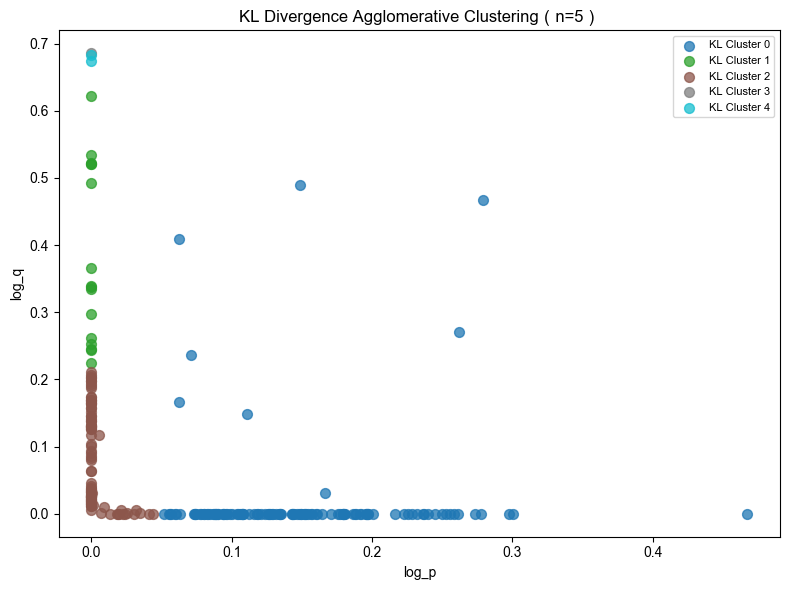

已儲存：../data/output/kl_cluster_viz.png


In [235]:
from sklearn.cluster import AgglomerativeClustering

T   = 30
EPS = 1e-10
N_KL_CLUSTERS = 5

# ── 1. 用 Bass Model 產生 t=1~30 的增量觀看曲線，正規化為機率分布 ──
df_kl = df[['reels_shortcode', 'p_after4d', 'q_after4d', 'M_after4d',
            'log_p', 'log_q']].dropna().reset_index(drop=True)
print(f'有效樣本數：{len(df_kl)}')

def bass_incremental(p, q, M, T=30):
    p  = max(p, EPS)
    q  = max(q, EPS)
    t  = np.arange(1, T + 1)
    F  = M * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))
    inc = np.diff(np.concatenate([[0], F]))
    return np.maximum(inc, 0)

curves = np.array([
    bass_incremental(r.p_after4d, r.q_after4d, r.M_after4d)
    for r in df_kl.itertuples()
])
# 正規化成機率分布
row_sums = curves.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1          # 避免除以零
curves_prob = curves / row_sums

# ── 2. 對稱 KL Divergence 距離矩陣（223×223）──
n = len(df_kl)

def sym_kl(P, Q, eps=EPS):
    P = P + eps;  P /= P.sum()
    Q = Q + eps;  Q /= Q.sum()
    return 0.5 * (np.sum(P * np.log(P / Q)) + np.sum(Q * np.log(Q / P)))

dist_mat = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        d = sym_kl(curves_prob[i], curves_prob[j])
        dist_mat[i, j] = d
        dist_mat[j, i] = d

print(f'距離矩陣 shape：{dist_mat.shape}')
print(f'非零距離  min={dist_mat[dist_mat > 0].min():.4f}  '
      f'max={dist_mat.max():.4f}  '
      f'mean={dist_mat[dist_mat > 0].mean():.4f}')

# ── 3. Agglomerative Clustering（average linkage，自訂距離矩陣）──
agg = AgglomerativeClustering(
    n_clusters=N_KL_CLUSTERS, metric='precomputed', linkage='average'
)
df_kl['kl_cluster'] = agg.fit_predict(dist_mat)

print('\n各 KL Cluster 大小：')
print(df_kl['kl_cluster'].value_counts().sort_index().to_string())

print('\n各 Cluster p_after4d / q_after4d mean & std：')
print(
    df_kl.groupby('kl_cluster')[['p_after4d', 'q_after4d']]
         .agg(['mean', 'std']).round(5).to_string()
)

# ── 4. 散點圖：log_p vs log_q，顏色代表 kl_cluster ──
cmap_kl = plt.cm.get_cmap('tab10', N_KL_CLUSTERS)
fig, ax  = plt.subplots(figsize=(8, 6))
for c in range(N_KL_CLUSTERS):
    mask_c = df_kl['kl_cluster'] == c
    ax.scatter(df_kl.loc[mask_c, 'log_p'], df_kl.loc[mask_c, 'log_q'],
               color=cmap_kl(c), alpha=0.75, s=50, label=f'KL Cluster {c}')
ax.set_xlabel('log_p')
ax.set_ylabel('log_q')
ax.set_title(f'KL Divergence Agglomerative Clustering（n={N_KL_CLUSTERS}）')
ax.legend(fontsize=8)
plt.tight_layout()
kl_path = OUTPUT / 'kl_cluster_viz.png'
plt.savefig(kl_path, dpi=150)
plt.show()
print(f'已儲存：{kl_path}')

合併後各 KL Cluster 大小：
kl_cluster_4
0    118
1     16
2     87
3      3
KL Cluster 0: 92 筆 train → 迴歸完成
KL Cluster 1: 14 筆 train → 迴歸完成
KL Cluster 2: 70 筆 train → 迴歸完成
KL Cluster 3: 3 筆 train → 迴歸完成

=== KL 4-Cluster 迴歸評估（test set）===
 cluster       target  n_test            R²   RMSE
       0        log_p      26 -3.330000e-02 0.0963
       0        log_q      26  1.187000e-01 0.0980
       0 log_constant      26  1.427000e-01 3.3760
       1        log_p       2 -4.727516e+13 0.0000
       1        log_q       2 -2.208880e+01 0.3047
       1 log_constant       2 -1.332950e+01 3.6775
       2        log_p      17  8.520000e-02 0.0085
       2        log_q      17 -2.583000e-01 0.0637
       2 log_constant      17  1.000000e-02 1.3303


/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_26361/1371852537.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap4  = plt.cm.get_cmap('tab10', N_MERGED)


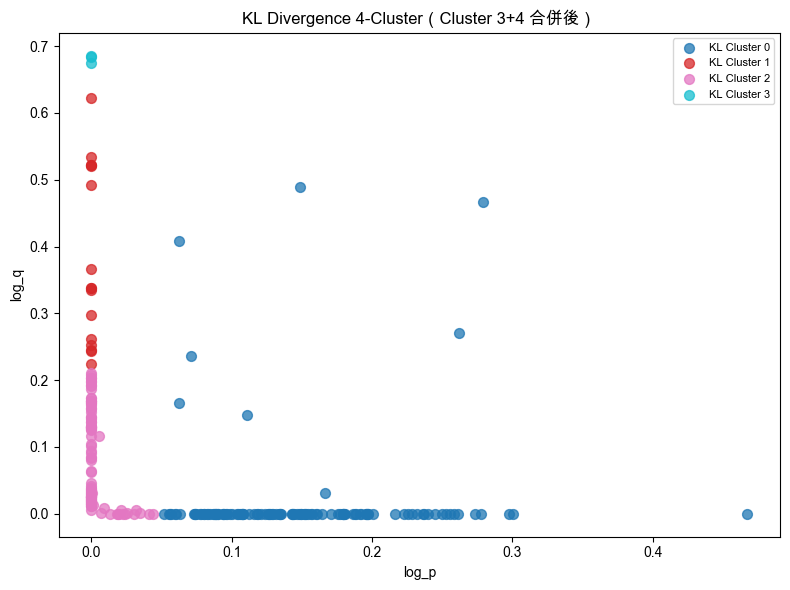

已儲存：../data/output/kl_cluster_merged_viz.png


In [236]:
# ── Cluster 3 和 Cluster 4 合併 → 統一標為 cluster 3，共 4 群 ──
N_MERGED = 4
df_kl['kl_cluster_4'] = df_kl['kl_cluster'].replace({4: 3})

print('合併後各 KL Cluster 大小：')
print(df_kl['kl_cluster_4'].value_counts().sort_index().to_string())

# kl_labels 與 df 的列順序一致（df_kl 由 df.dropna().reset_index() 產生）
kl_labels = df_kl['kl_cluster_4'].values

# ── Per-Cluster LinearRegression（train set）──
kl_models = {}
for c in range(N_MERGED):
    mask_c = kl_labels[train_idx] == c
    n_c    = mask_c.sum()
    if n_c < 2:
        print(f'KL Cluster {c}: 只有 {n_c} 筆，使用全體中位數 fallback')
        kl_models[c] = None
        continue
    X_c = X_all[train_idx][mask_c]
    kl_models[c] = {
        t: LinearRegression().fit(X_c, df[t].values[train_idx][mask_c])
        for t in targets
    }
    print(f'KL Cluster {c}: {n_c} 筆 train → 迴歸完成')

# ── 評估（test set）：R² 和 RMSE ──
print('\n=== KL 4-Cluster 迴歸評估（test set）===')
rows = []
for c in range(N_MERGED):
    mask_c = kl_labels[test_idx] == c
    if mask_c.sum() == 0:
        continue
    X_tc = X_all[test_idx][mask_c]
    for t in targets:
        y_true = df[t].values[test_idx][mask_c]
        y_pred = (
            kl_models[c][t].predict(X_tc)
            if kl_models[c] is not None
            else np.full(mask_c.sum(), global_fallback[t])
        )
        rows.append({
            'cluster': c,
            'target' : t,
            'n_test' : int(mask_c.sum()),
            'R²'     : round(r2_score(y_true, y_pred), 4),
            'RMSE'   : round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        })

print(pd.DataFrame(rows).to_string(index=False))

# ── 散點圖：log_p vs log_q，顏色代表合併後 4 群 ──
cmap4  = plt.cm.get_cmap('tab10', N_MERGED)
fig, ax = plt.subplots(figsize=(8, 6))
for c in range(N_MERGED):
    mask_c = kl_labels == c
    ax.scatter(df_kl.loc[mask_c, 'log_p'], df_kl.loc[mask_c, 'log_q'],
               color=cmap4(c), alpha=0.75, s=50, label=f'KL Cluster {c}')
ax.set_xlabel('log_p')
ax.set_ylabel('log_q')
ax.set_title('KL Divergence 4-Cluster（Cluster 3+4 合併後）')
ax.legend(fontsize=8)
plt.tight_layout()
kl4_path = OUTPUT / 'kl_cluster_merged_viz.png'
plt.savefig(kl4_path, dpi=150)
plt.show()
print(f'已儲存：{kl4_path}')

=== DBSCAN 各 eps 結果 ===

eps=0.3  →  cluster 數=1，噪音點=4
  噪音（-1）: 4 筆
  Cluster 0: 220 筆

eps=0.5  →  cluster 數=1，噪音點=3
  噪音（-1）: 3 筆
  Cluster 0: 221 筆

eps=1.0  →  cluster 數=1，噪音點=1
  噪音（-1）: 1 筆
  Cluster 0: 223 筆

eps=2.0  →  cluster 數=1，噪音點=1
  噪音（-1）: 1 筆
  Cluster 0: 223 筆

選定 eps = 2.0（cluster 數=-1，噪音=inf）


/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_26361/734607856.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_db = plt.cm.get_cmap('tab10', max(len(unique_clusters), 1))


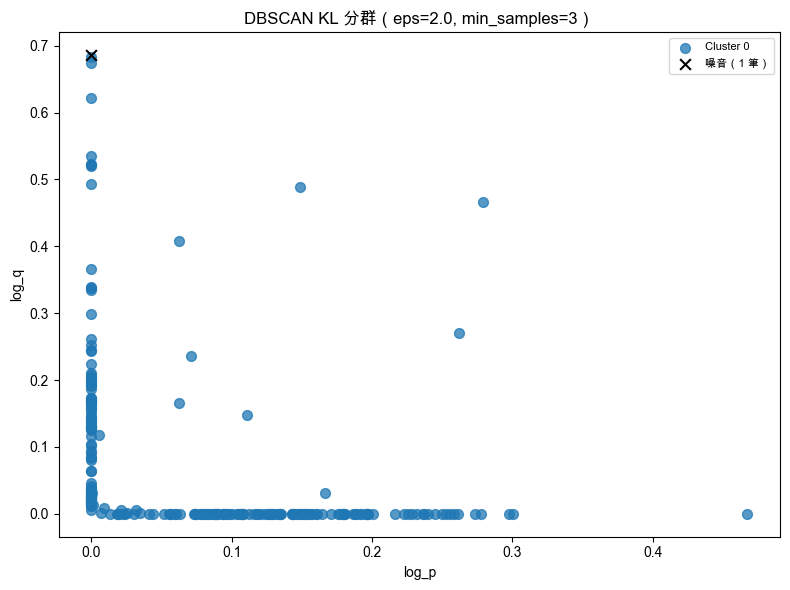

已儲存：../data/output/dbscan_cluster.png


In [237]:
from sklearn.cluster import DBSCAN

eps_list    = [0.3, 0.5, 1.0, 2.0]
dbscan_results = {}

# ── 1. 試四個 eps，印群數和每群大小 ──
print('=== DBSCAN 各 eps 結果 ===')
for eps in eps_list:
    labels = DBSCAN(metric='precomputed', eps=eps, min_samples=3).fit_predict(dist_mat)
    counts = pd.Series(labels).value_counts().sort_index()
    n_clusters = int((labels >= 0).any() and labels.max() + 1)
    n_noise    = int((labels == -1).sum())
    print(f'\neps={eps}  →  cluster 數={n_clusters}，噪音點={n_noise}')
    for lbl, cnt in counts.items():
        name = f'Cluster {lbl}' if lbl >= 0 else '噪音（-1）'
        print(f'  {name}: {cnt} 筆')
    dbscan_results[eps] = labels

# ── 2. 自動選 eps：有 ≥2 群且噪音最少 ──
best_eps = None
best_score = (-1, float('inf'))   # (n_clusters, n_noise)

for eps, labels in dbscan_results.items():
    n_clusters = int(labels.max()) + 1 if labels.max() >= 0 else 0
    n_noise    = int((labels == -1).sum())
    if n_clusters >= 2:
        if n_clusters > best_score[0] or (
                n_clusters == best_score[0] and n_noise < best_score[1]):
            best_score = (n_clusters, n_noise)
            best_eps   = eps

if best_eps is None:          # 所有 eps 都只有 1 群或全噪音，取最大 eps
    best_eps = max(eps_list)

best_labels = dbscan_results[best_eps]
print(f'\n選定 eps = {best_eps}（cluster 數={best_score[0]}，噪音={best_score[1]}）')

# ── 3. 散點圖：顏色代表 cluster，噪音點用黑色 × ──
unique_clusters = sorted(set(best_labels) - {-1})
cmap_db = plt.cm.get_cmap('tab10', max(len(unique_clusters), 1))

fig, ax = plt.subplots(figsize=(8, 6))
for c in unique_clusters:
    mask_c = best_labels == c
    ax.scatter(df_kl.loc[mask_c, 'log_p'], df_kl.loc[mask_c, 'log_q'],
               color=cmap_db(c), alpha=0.75, s=50, label=f'Cluster {c}')

noise_mask = best_labels == -1
if noise_mask.sum() > 0:
    ax.scatter(df_kl.loc[noise_mask, 'log_p'], df_kl.loc[noise_mask, 'log_q'],
               c='black', marker='x', s=60, linewidths=1.5,
               zorder=5, label=f'噪音（{noise_mask.sum()} 筆）')

ax.set_xlabel('log_p')
ax.set_ylabel('log_q')
ax.set_title(f'DBSCAN KL 分群（eps={best_eps}, min_samples=3）')
ax.legend(fontsize=8)
plt.tight_layout()
db_path = OUTPUT / 'dbscan_cluster.png'
plt.savefig(db_path, dpi=150)
plt.show()
print(f'已儲存：{db_path}')

## 6. 對 hist_features 預測

In [238]:
hist = pd.read_csv(PROCESSED / 'hist_features.csv', low_memory=False)
print('hist_features shape:', hist.shape)

# 編碼 hist 的類別特徵
known_labels = set(le.classes_)
hist['best_topic_labels_enc'] = le.transform(
    hist['best_topic_labels'].fillna('unknown')
         .apply(lambda x: x if x in known_labels else 'unknown')
)
hist['AI業配判定_enc'] = (
    hist['AI業配判定']
    .map({True: 1, 'True': 1, False: 0, 'False': 0})
    .fillna(0).astype(int)
)

# 用 train 中位數填補缺值，套用同一 scaler
hist_feat = hist[selected_features].fillna(medians_sel[selected_features])
X_hist    = scaler.transform(hist_feat.values)
print('X_hist shape:', X_hist.shape)

hist_features shape: (10375, 1083)
X_hist shape: (10375, 5)


/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_26361/3576025474.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hist['best_topic_labels_enc'] = le.transform(
/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_26361/3576025474.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hist['AI業配判定_enc'] = (


In [239]:
# 全局 LinearRegression：用全部 224 筆 fit，不分 cluster
global_models = {
    t: LinearRegression().fit(X_all, df[t].values)
    for t in targets
}

# 印出全局公式係數
print('=== 全局迴歸公式 ===')
for t in targets:
    model = global_models[t]
    terms = ' + '.join(
        f'{coef:.4f} * {feat}'
        for coef, feat in zip(model.coef_, selected_features)
    )
    print(f'\n{t} 公式：')
    print(f'  {t} = {terms} + {model.intercept_:.4f}（截距）')

# 對 hist_features 預測（log scale）
log_p_pred     = global_models['log_p'].predict(X_hist)
log_q_pred     = global_models['log_q'].predict(X_hist)
log_const_pred = global_models['log_constant'].predict(X_hist)

=== 全局迴歸公式 ===

log_p 公式：
  log_p = -0.0152 * emb_new_256 + 0.0005 * emb_new_095 + -0.0027 * duration + -0.0052 * emb_new_067 + 0.0016 * emb_new_409 + 0.0802（截距）

log_q 公式：
  log_q = 0.0174 * emb_new_256 + 0.0242 * emb_new_095 + 0.0295 * duration + 0.0239 * emb_new_067 + -0.0210 * emb_new_409 + 0.0774（截距）

log_constant 公式：
  log_constant = -0.4439 * emb_new_256 + -0.0413 * emb_new_095 + -0.1241 * duration + -0.0986 * emb_new_067 + 0.3285 * emb_new_409 + 10.0158（截距）


In [240]:
hist_p     = np.expm1(log_p_pred).clip(0)
hist_q     = np.expm1(log_q_pred).clip(0)
hist_const = np.expm1(log_const_pred).clip(0)

out_df = pd.DataFrame({
    'reels_shortcode': hist['reels_shortcode'].values,
    'p'              : hist_p,
    'q'              : hist_q,
    'M'              : hist['views'].values,
    'constant'       : hist_const,
})

out_path = OUTPUT / 'augmented_hist.csv'
out_df.to_csv(out_path, index=False)
print(f'已儲存：{out_path}')
print(out_df.shape)
print(out_df.head())

已儲存：../data/output/augmented_hist.csv
(10375, 5)
  reels_shortcode         p         q    M      constant
0     DPeT4BHExo-  0.082518  0.084187  243  21674.517627
1     DPZEm_oExnd  0.082571  0.083600  266  21723.970242
2     DLvRZSlTBzn  0.082891  0.080065   37  22024.823827
3     DIvNtToTBL-  0.082724  0.081905  231  21867.580420
4     Ciksu1-vDBo  0.083107  0.077682  309  22230.445702
